In [16]:
#Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, roc_curve, auc
from sklearn.linear_model import LinearRegression

In [2]:
#Read in merged data
merged_data = pd.read_csv('/Users/juliaesposito/CSYS_5870/Semester_project/all_merged_df.csv')

In [3]:
merged_data['median_household_income'] = pd.to_numeric(merged_data['median_household_income'], errors = "coerce")

In [4]:
#Make fips as string
merged_data['fips'] = merged_data['fips'].astype(str)

In [5]:
#Calculate various measures of change over time

fi = merged_data[["fips", "year", "food_insecurity_rate"]]

#Overall mean 2010-2022
fi_mean_10_22 = fi.groupby("fips")["food_insecurity_rate"].mean().rename("fi_mean_10_22")

#Recent/Short-term exposure mean 2020-2022
fi_short = fi[fi["year"] >= 2020].groupby("fips")["food_insecurity_rate"].mean().rename("fi_short")

#Medium-term exposure mean
fi_medium = fi[fi["year"].isin([2015, 2016, 2017, 2018, 2019])].groupby("fips")["food_insecurity_rate"].mean().rename("fi_medium")

#Medium-term cumulative exposure
fi_medium_cumulative = fi[fi["year"].isin([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])].groupby("fips")["food_insecurity_rate"].mean().rename("fi_medium_cumulative")

#Long-term exposure mean
fi_long = fi[fi["year"].isin([2010, 2011, 2012, 2013, 2014])].groupby("fips")["food_insecurity_rate"].mean().rename("fi_long")

#Food insecurity volatility - how much is a county's food insecurity rate fluctuating
fi_volatility_10_22 = fi.groupby("fips")["food_insecurity_rate"].std().rename("fi_volatility_10_22")

#Crude change between 2010 and 2022
fi_2010 = fi[fi["year"] == 2010].set_index("fips")["food_insecurity_rate"]
fi_2022 = fi[fi["year"] == 2022].set_index("fips")["food_insecurity_rate"]
fi_change_10_22 = (fi_2022 - fi_2010).rename("fi_change_10_22")


def calc_slope(group):
    years = group["year"].values
    fi_values = group["food_insecurity_rate"].values
    slope = np.polyfit(years, fi_values, 1)[0]
    return slope

fi_trend = fi.groupby("fips").apply(calc_slope).rename("fi_trend")

/var/folders/cw/f9qklq2518177kb19y3vjmhr0000gn/T/ipykernel_48743/2568948671.py:32: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, fi_values, 1)[0]
/var/folders/cw/f9qklq2518177kb19y3vjmhr0000gn/T/ipykernel_48743/2568948671.py:32: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, fi_values, 1)[0]
/var/folders/cw/f9qklq2518177kb19y3vjmhr0000gn/T/ipykernel_48743/2568948671.py:32: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, fi_values, 1)[0]
/var/folders/cw/f9qklq2518177kb19y3vjmhr0000gn/T/ipykernel_48743/2568948671.py:32: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, fi_values, 1)[0]
/var/folders/cw/f9qklq2518177kb19y3vjmhr0000gn/T/ipykernel_48743/2568948671.py:32: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, fi_values, 1)[0]
/var/folders/cw/f9qklq2518177kb19y3vjmhr0000gn/T/ipykernel_48743/2568948671.py:32: RankWarning: Polyfit may be poorly conditi

In [6]:
#Merge all the change measures into one dataframe

fi_features = (
    pd.concat([fi_mean_10_22, fi_short, fi_medium, fi_medium_cumulative, fi_long, fi_volatility_10_22, fi_change_10_22, fi_trend], axis=1)
      .reset_index()
)

In [7]:
#Merge change measures with health and census data
census_health_df = merged_data[merged_data["year"] == 2022]

census_health_df = census_health_df[['fips', 'state_name', 'obesity_rate', 'diabetes_rate', 'median_household_income', 'per_families_wo_employment', 'per_col_grad', 'per_hs_grad', 'per_white_only', 'per_over65']].drop_duplicates("fips")

final_df = fi_features.merge(census_health_df, on="fips", how="inner")
final_df

,fips,fi_mean_10_22,fi_short,fi_medium,fi_medium_cumulative,fi_long,fi_volatility_10_22,fi_change_10_22,fi_trend,state_name,obesity_rate,diabetes_rate,median_household_income,per_families_wo_employment,per_col_grad,per_hs_grad,per_white_only,per_over65
0,10001,0.127615,0.124667,0.1282,0.126875,0.1288,0.006199,0.010,-0.000302,de,0.393,0.111,69278.0,0.177,0.263,0.889,0.614,0.176
1,10003,0.113462,0.104667,0.1120,0.109250,0.1202,0.009043,-0.001,-0.001593,de,0.376,0.116,85309.0,0.130,0.383,0.925,0.586,0.162
2,10005,0.107308,0.114333,0.1036,0.107625,0.1068,0.009141,0.021,0.000819,de,0.386,0.099,75406.0,0.262,0.317,0.901,0.780,0.292
3,1001,0.139917,0.143000,0.1405,0.141571,0.1376,0.007856,0.017,0.000933,al,0.384,0.113,68315.0,0.179,0.296,0.904,0.744,0.156
4,1003,0.130538,0.130333,0.1264,0.127875,0.1348,0.008847,0.015,-0.000319,al,0.368,0.102,71039.0,0.203,0.326,0.916,0.840,0.212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3139,9150,0.127000,0.127000,NaN,0.127000,NaN,NaN,NaN,0.000031,ct,0.328,0.084,83119.0,0.154,0.250,0.913,0.852,0.171
3140,9160,0.127000,0.127000,NaN,0.127000,NaN,NaN,NaN,0.000031,ct,0.306,0.082,87971.0,0.144,0.379,0.932,0.823,0.204
3141,9170,0.135000,0.135000,NaN,0.135000,NaN,NaN,NaN,0.000033,ct,0.320,0.096,83617.0,0.130,0.404,0.914,0.675,0.175
3142,9180,0.134000,0.134000,NaN,0.134000,NaN,NaN,NaN,0.000033,ct,0.334,0.091,80330.0,0.162,0.338,0.924,0.789,0.189


In [8]:
#Remove NAs for analyses
final_df = final_df.dropna()

Produce Random Forest Classifier to predict whether counties will have above average diabetes rates based on FI mean and SES factors

In [9]:
avg_diabetes = final_df["diabetes_rate"].mean()

avg_obesity = final_df["obesity_rate"].mean()

final_df["above_avg_diabetes"] = (final_df["diabetes_rate"] > avg_diabetes).astype(int)
final_df["above_avg_obesity"] = (final_df["obesity_rate"] > avg_obesity).astype(int)

/var/folders/cw/f9qklq2518177kb19y3vjmhr0000gn/T/ipykernel_48743/3288974976.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df["above_avg_diabetes"] = (final_df["diabetes_rate"] > avg_diabetes).astype(int)
/var/folders/cw/f9qklq2518177kb19y3vjmhr0000gn/T/ipykernel_48743/3288974976.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df["above_avg_obesity"] = (final_df["obesity_rate"] > avg_obesity).astype(int)


Predicting Diabetes Rates Above National Average

In [10]:
X = final_df[['fi_mean_10_22', 'median_household_income', 'per_hs_grad', 'per_white_only', 'per_over65']]

y = final_df['above_avg_diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators = 300,
    max_depth = None,
    random_state = 42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall/Specificity:", recall_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8610223642172524
Precision: 0.8478260869565217
Recall/Specificity: 0.8387096774193549
[[305  42]
 [ 45 234]]
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       347
           1       0.85      0.84      0.84       279

    accuracy                           0.86       626
   macro avg       0.86      0.86      0.86       626
weighted avg       0.86      0.86      0.86       626



Confusion matrix output is [[TN, FP
                             FN, TP]]

The false positives may be of greatest interest here because they could be considered 'at risk' of developing a higher than average diabetes rate due to their FI rate and socioeconomic factors OR we can look into what it is about these communities that enable them to have a lower than average rate of diabetes. Is it an unobserved factor like access to services, etc.?

In [11]:
importances = rf.feature_importances_
for feat, imp in zip(X.columns, importances):
    print(f"{feat}: {imp:.3f}")


fi_mean_10_22: 0.271
median_household_income: 0.174
per_hs_grad: 0.318
per_white_only: 0.135
per_over65: 0.102


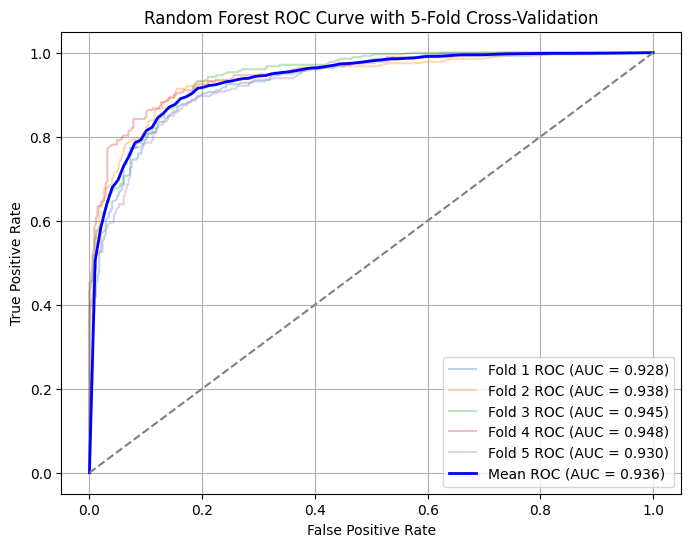

In [12]:
X = final_df[['fi_mean_10_22', 'median_household_income', 'per_hs_grad', 'per_white_only', 'per_over65']]

y = final_df['above_avg_diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators = 300,
    max_depth = None,
    random_state = 42
)
kf = StratifiedKFold(n_splits = 5, shuffle = True, random_state=42)

tprs = []
aucs = []

mean_fpr = np.linspace(0,1,100)

plt.figure(figsize=(8,6))

for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Fit model
    rf.fit(X_train, y_train)

    # Predict probabilities
    y_prob = rf.predict_proba(X_test)[:, 1]

    # Compute ROC curve + AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    # Interpolate ROC for mean curve
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0

    # Plot each fold
    plt.plot(fpr, tpr, alpha=0.3, label=f"Fold {fold} ROC (AUC = {roc_auc:.3f})")

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)

plt.plot(
    mean_fpr, mean_tpr,
    color="blue",
    lw=2,
    label=f"Mean ROC (AUC = {mean_auc:.3f})"
)

# Plot chance line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Formatting
plt.title("Random Forest ROC Curve with 5-Fold Cross-Validation")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

High school education attainment is most important for predicting diabetes rates but food insecurity rate is also very important. Least important is age structure and median household income.

Predicting Above Average Obesity Rate Above National Average

In [13]:
X = final_df[['fi_mean_10_22', 'median_household_income', 'per_hs_grad', 'per_white_only', 'per_over65']]

y = final_df['above_avg_obesity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators = 300,
    max_depth = None,
    random_state = 42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7124600638977636
[[172 109]
 [ 71 274]]
              precision    recall  f1-score   support

           0       0.71      0.61      0.66       281
           1       0.72      0.79      0.75       345

    accuracy                           0.71       626
   macro avg       0.71      0.70      0.70       626
weighted avg       0.71      0.71      0.71       626



In [14]:
importances = rf.feature_importances_
for feat, imp in zip(X.columns, importances):
    print(f"{feat}: {imp:.3f}")

fi_mean_10_22: 0.193
median_household_income: 0.281
per_hs_grad: 0.207
per_white_only: 0.150
per_over65: 0.168


Most important is median household income.

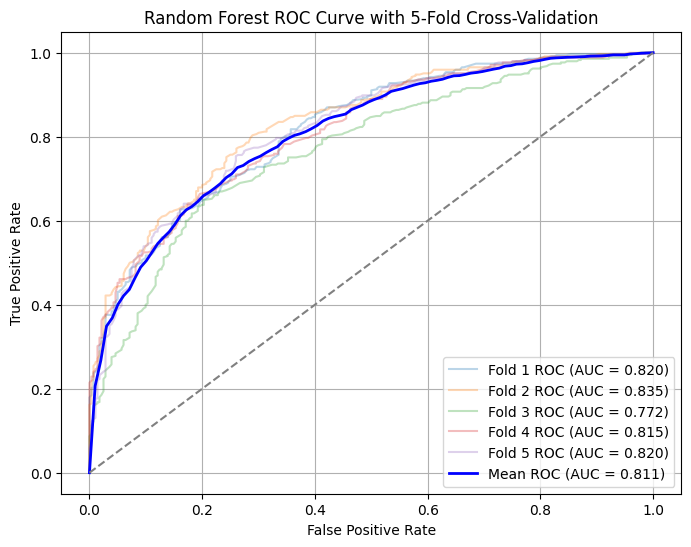

In [15]:
X = final_df[['fi_mean_10_22', 'median_household_income', 'per_hs_grad', 'per_white_only', 'per_over65']]

y = final_df['above_avg_obesity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators = 300,
    max_depth = None,
    random_state = 42
)
kf = StratifiedKFold(n_splits = 5, shuffle = True, random_state=42)

tprs = []
aucs = []

mean_fpr = np.linspace(0,1,100)

plt.figure(figsize=(8,6))

for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Fit model
    rf.fit(X_train, y_train)

    # Predict probabilities
    y_prob = rf.predict_proba(X_test)[:, 1]

    # Compute ROC curve + AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    # Interpolate ROC for mean curve
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0

    # Plot each fold
    plt.plot(fpr, tpr, alpha=0.3, label=f"Fold {fold} ROC (AUC = {roc_auc:.3f})")

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)

plt.plot(
    mean_fpr, mean_tpr,
    color="blue",
    lw=2,
    label=f"Mean ROC (AUC = {mean_auc:.3f})"
)

# Plot chance line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Formatting
plt.title("Random Forest ROC Curve with 5-Fold Cross-Validation")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()